In [1]:
# reload modules before execution (for the changing code in Src)
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

SRC_FOLDER = Path(Path.cwd().parent / "Src").resolve()
sys.path.append(str(SRC_FOLDER))
import preparation

UTILS_FOLDER = Path(Path().cwd().parent.parent / "rabbit_holes" / "src").resolve()
sys.path.append(str(UTILS_FOLDER))
import plotting_tools

MAP_PLOTTING_TOOLS_FOLDER = Path(Path.cwd().parent.parent / "Curated_Data_SQLite" / "src").resolve()
sys.path.append(str(MAP_PLOTTING_TOOLS_FOLDER))
import utils as map_plotting

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
Path(Path.cwd().parent.parent / "Curated_Data_SQLite" / "src").resolve()

PosixPath('/home/mbr/Curated_Data_SQLite/src')

In [4]:
PROCESSED_DATA_FOLDER = Path("../Data/Processed/").resolve()
bicliques_fn = "bicliques_wave_5.csv"
data_fn = "base_values_wave_5.parquet"
data, complete_data = preparation.import_bicliques(PROCESSED_DATA_FOLDER / data_fn, PROCESSED_DATA_FOLDER / bicliques_fn)
labels = pd.read_csv(PROCESSED_DATA_FOLDER / "clusters_5.csv", index_col=0)

In [5]:
subm_most_rows = complete_data[0]
la_idx, subm_largest_area = max(enumerate(complete_data), key=lambda pair: pair[1].size)

# Cluster visualization

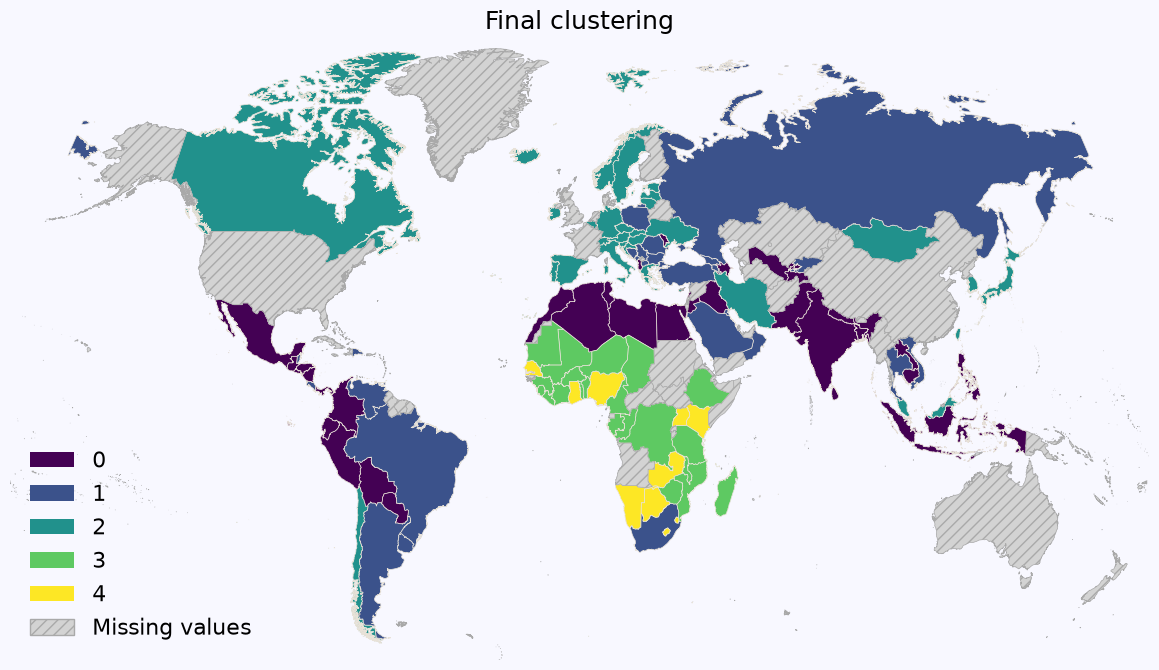

In [6]:
clusters = labels["final"].unique()
colors = cm.viridis(np.linspace(0, 1, len(clusters)))
palette = {cluster: mcolors.to_hex(color) for cluster, color in zip(clusters, colors)}
map_plotting.plot_cluster_map(
    labels["final"], 
    {l: str(l) for l in clusters}, 
    palette,
    title="Final clustering"
)

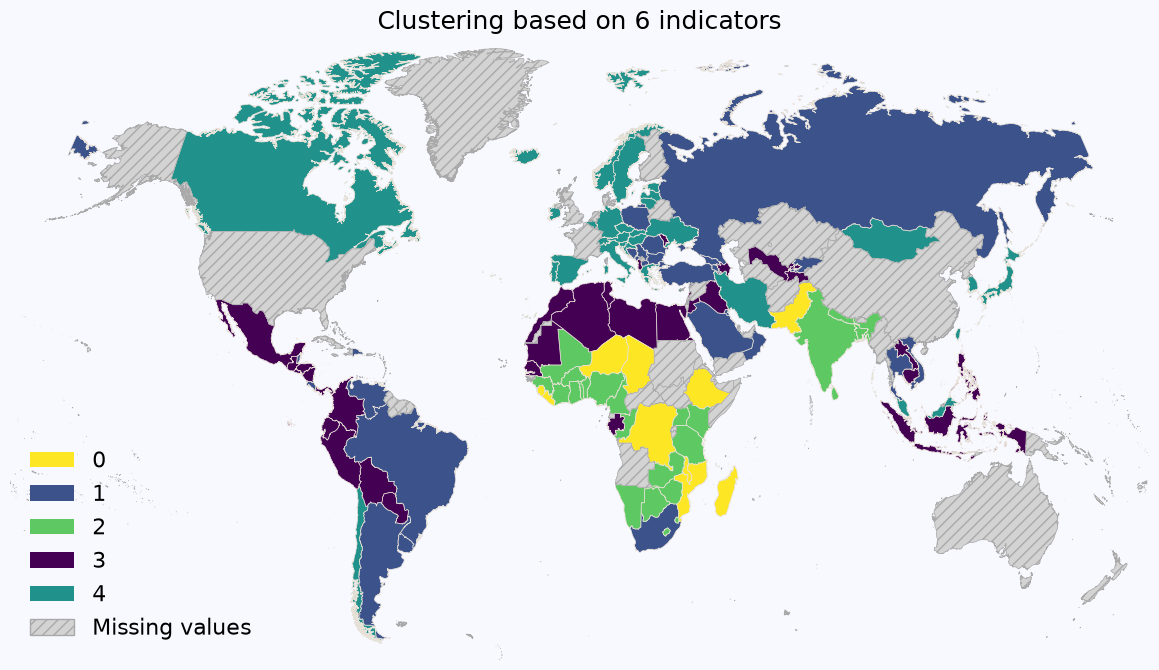

In [7]:
clusters = labels["0"].unique()
colors = cm.viridis(np.linspace(0, 1, len(clusters)))
palette = {cluster: mcolors.to_hex(color) for cluster, color in zip(clusters, colors)}
map_plotting.plot_cluster_map(
    labels["0"], 
    {l: str(l) for l in clusters}, 
    palette,
    title="Clustering based on 6 indicators"
)

In [8]:
X = StandardScaler().fit_transform(subm_most_rows)
X_PCA = PCA().fit_transform(X)
X_tSNE = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        #random_state=42
    ).fit_transform(X)

Y = StandardScaler().fit_transform(subm_largest_area)
Y_PCA = PCA().fit_transform(Y)
Y_tSNE = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        #random_state=42
    ).fit_transform(Y)

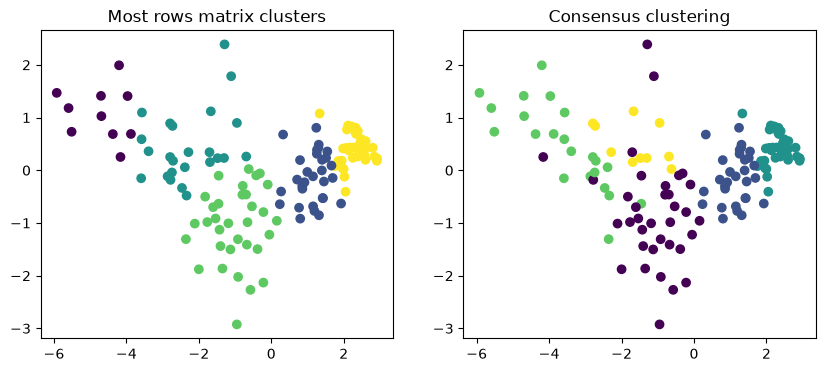

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_PCA[:, 0], X_PCA[:, 1], c=labels['0'])
ax[0].set_title("Most rows matrix clusters")

ax[1].scatter(X_PCA[:, 0], X_PCA[:, 1], c=labels['final'])
ax[1].set_title("Consensus clustering")
plt.show()

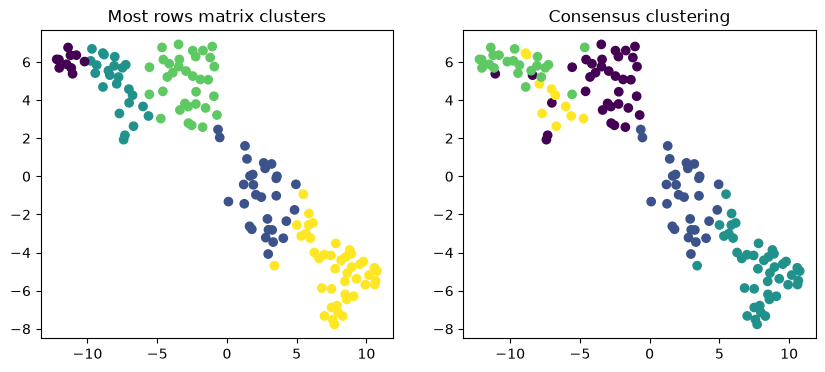

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_tSNE[:, 0], X_tSNE[:, 1], c=labels['0'])
ax[0].set_title("Most rows matrix clusters")

ax[1].scatter(X_tSNE[:, 0], X_tSNE[:, 1], c=labels['final'])
ax[1].set_title("Consensus clustering")
plt.show()

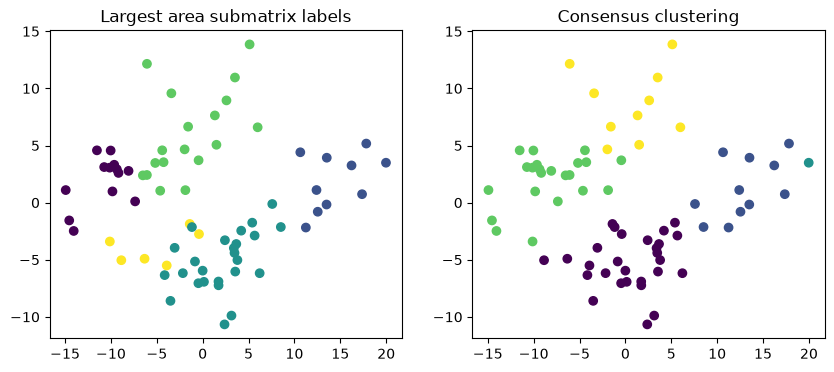

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(Y_PCA[:, 0], Y_PCA[:, 1], c=labels.loc[subm_largest_area.index, str(la_idx)])
ax[0].set_title("Largest area submatrix labels")

ax[1].scatter(Y_PCA[:, 0], Y_PCA[:, 1], c=labels.loc[subm_largest_area.index, "final"])
ax[1].set_title("Consensus clustering")
plt.show()

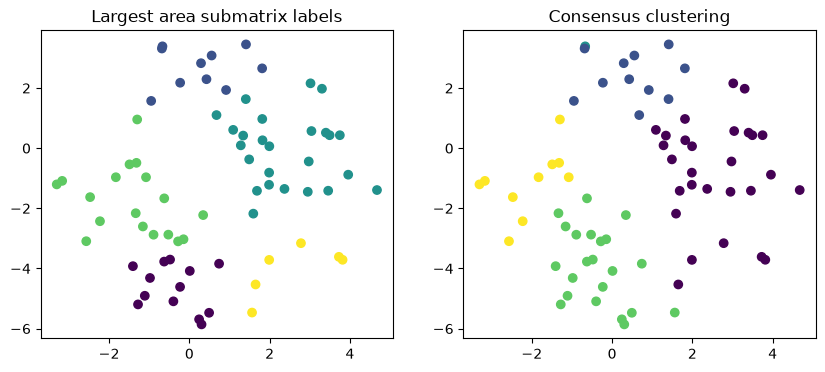

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(Y_tSNE[:, 0], Y_tSNE[:, 1], c=labels.loc[subm_largest_area.index, str(la_idx)])
ax[0].set_title("Largest area submatrix labels")

ax[1].scatter(Y_tSNE[:, 0], Y_tSNE[:, 1], c=labels.loc[subm_largest_area.index, "final"])
ax[1].set_title("Consensus clustering")
plt.show()

# Cluster profiling

In [13]:
final_cluster_profiles = (
    data.assign(final=labels['final'])
    .groupby(by='final')
    .agg(["mean", "median", "std"])
)

In [14]:
final_cluster_profiles.loc[:, subm_most_rows.columns]

series_id account.t.d                             con1                        \
                 mean     median        std       mean     median        std   
final                                                                          
0           48.318295  46.069251  14.725524  85.353716  85.302162   8.007929   
1           78.341011  78.832296   7.689272  93.347197  93.599326   3.009215   
2           95.316809  97.971829   4.769126  95.875216  96.759944   2.923158   
3           46.346716  50.898582  14.077644  71.525236  75.130623  13.469679   
4           71.765933  72.764900   9.304725  84.252839  84.979918   4.936388   

series_id      con9a                       fiaccount.t.d             \
                mean     median        std          mean     median   
final                                                                 
0          67.123576  69.003766  12.833295     44.643379  42.461132   
1          81.351176  82.075694   6.929683     77.542596  77.706363   
2          88.571495  88.761948   4.937010     95.273241  97.864756   
3          31.250139  27.557801  15.773396     21.035556  19.176853   
4          45.047235  47.048105  11.370425     42.315862  42.369989   

series_id              fin2.t.d                         internet             \
                 std       mean     median        std       mean     median   
final                                                                         
0          15.286096  28.697839  27.230239  12.125651  72.094614  75.289082   
1           7.720853  65.067986  65.129643  10.934215  86.412423  87.433353   
2           4.820239  89.834468  89.383676   5.812542  92.110267  92.934670   
3           9.483499   7.973337   7.407383   4.228272  33.403797  32.416668   
4          12.674175  26.214393  23.796573  13.781135  50.131549  49.419921   

series_id             
                 std  
final                 
0          14.496377  
1           6.387778  
2           4.768491  
3          15.024806  
4          10.633909

In [15]:
most_rows_cluster_profiles = (
    subm_most_rows.assign(labels=labels["0"])
    .groupby(by='labels')
    .agg(["mean", "median", "std"])
)

In [16]:
most_rows_cluster_profiles

series_id account.t.d                             con1                       \
                 mean     median        std       mean     median       std   
labels                                                                        
0           37.110511  38.917266  14.385166  57.853210  58.493673  6.569878   
1           78.341011  78.832296   7.689272  93.347197  93.599326  3.009215   
2           62.313066  60.432453  13.912840  81.023113  80.880388  6.014348   
3           47.327537  46.069251  13.221133  87.284146  87.312934  5.789339   
4           95.316809  97.971829   4.769126  95.875216  96.759944  2.923158   

series_id      con9a                       fiaccount.t.d             \
                mean     median        std          mean     median   
labels                                                                
0          19.035602  19.295341   7.699895     18.376820  14.442673   
1          81.351176  82.075694   6.929683     77.542596  77.706363   
2          40.982577  44.345680  10.693630     36.692270  32.694960   
3          70.101900  69.255325   8.276569     41.941710  39.577064   
4          88.571495  88.761948   4.937010     95.273241  97.864756   

series_id              fin2.t.d                         internet             \
                 std       mean     median        std       mean     median   
labels                                                                        
0          11.377875   6.380951   4.653570   4.465318  23.283357  23.805130   
1           7.720853  65.067986  65.129643  10.934215  86.412423  87.433353   
2          20.469277  18.218162  13.355584  13.535548  42.618507  43.646678   
3          11.367479  28.513221  27.230239  11.968632  75.873721  76.165886   
4           4.820239  89.834468  89.383676   5.812542  92.110267  92.934670   

series_id            
                std  
labels               
0          9.870356  
1          6.387778  
2          9.230638  
3          9.143318  
4          4.768491

## Mobile money adoption per cluster

In [161]:
mobile_acc_missing = data['mobileaccount.t.d'][data['mobileaccount.t.d'].isna()].index
mobile_acc_missing_per_cluster = labels.loc[mobile_acc_missing, 'final'].value_counts().reindex(sorted(labels["final"].unique()), fill_value=0).sort_index()

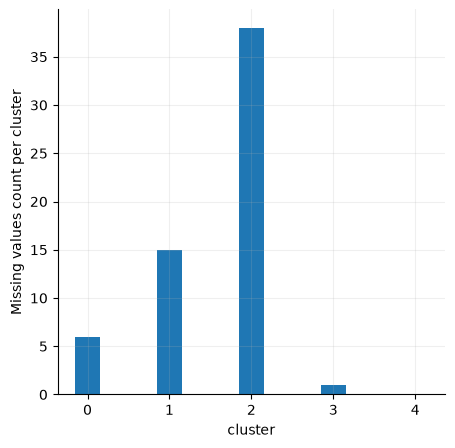

In [173]:
fig, ax = plt.subplots(figsize=(5,5))
ax.bar(mobile_acc_missing_per_cluster.index, mobile_acc_missing_per_cluster, width=0.3)
ax.set_xlabel("cluster")
ax.set_ylabel("Missing values count per cluster")
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(True, alpha = 0.2)
plt.show()

In [146]:
#mobile_account_levels, edges = map_plotting.divide_range_into_Gaussian_buckets(data['mobileaccount.t.d'][data['mobileaccount.t.d'].notna()])

mobile_acc_data = data['mobileaccount.t.d'][data['mobileaccount.t.d'].notna()]
min_mobile_acc_lvl = mobile_acc_data.min()
max_mobile_acc_lvl = mobile_acc_data.max()
mobile_account_levels, edges = map_plotting.divide_range_into_buckets(4, min_mobile_acc_lvl, max_mobile_acc_lvl, mobile_acc_data)

In [150]:
mobile_acc_data.describe()

count    80.000000
mean     32.345412
std      20.813910
min       2.645629
25%      13.583732
50%      31.909464
75%      48.402551
max      87.499411
Name: mobileaccount.t.d, dtype: float64

In [147]:
edges

[np.float64(0.0),
 np.float64(21.213445486649718),
 np.float64(42.426890973299436),
 np.float64(63.640336459949154),
 np.float64(84.85378194659887)]

In [174]:
counts = {}
for cluster in np.sort(mobile_account_levels.unique()):
    counts[cluster] = labels.loc[mobile_account_levels[mobile_account_levels == cluster].index, 'final'].value_counts()

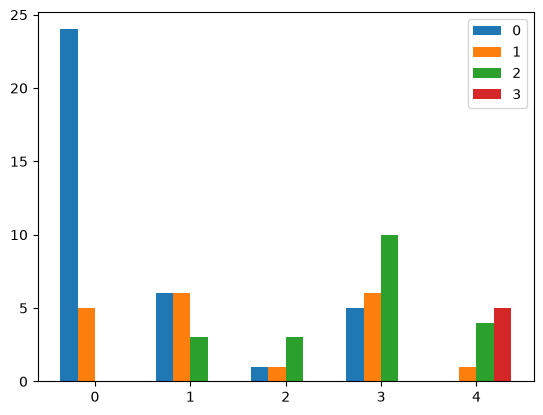

In [182]:
plt.grouped_bar(pd.DataFrame(counts).fillna(0).astype(int).to_dict(orient='list'))
plt.legend()
plt.show()

In [113]:
data['mobileaccount.t.d'].sort_values(ascending=False)

country_id
KEN    87.499411
GHA    78.281364
ZMB    69.310751
UGA    67.738295
SEN    66.912649
         ...    
UKR          NaN
URY          NaN
USA          NaN
UZB          NaN
XKX          NaN
Name: mobileaccount.t.d, Length: 140, dtype: float64

In [103]:
top_10_mobile_account = data['mobileaccount.t.d'].sort_values(ascending=False)[:10].index
top_20_mobile_account = data['mobileaccount.t.d'].sort_values(ascending=False)[:20].index
top_50_mobile_account = data['mobileaccount.t.d'].sort_values(ascending=False)[:50].index
top_mobile_account_in_clusters = labels.loc[top_20_mobile_account, "final"].value_counts()

cnt_cluster = labels["final"].value_counts()

for cluster, top in top_mobile_account_in_clusters.items():
    print(f"{cluster}: {top} out of {cnt_cluster[cluster]} ({top/cnt_cluster[cluster] * 100:.0f}%)")

4: 9 out of 10 (90%)
3: 5 out of 22 (23%)
2: 3 out of 43 (7%)
1: 3 out of 30 (10%)


In [94]:
mobile_money_profile = (
    pd.concat(
        [data["mobileaccount.t.d"], labels["final"]],
        axis=1
    )
    .groupby("final")["mobileaccount.t.d"]
    .agg(["count", "mean", "median", "min", "max"])
)

mobile_money_profile

,count,mean,median,min,max
final,,,,,
0,29,16.502394,14.430210,2.645629,42.497337
1,15,31.024881,31.623202,5.817619,58.166616
2,5,47.642109,56.468966,13.104010,64.030431
3,21,38.047695,44.872852,5.700371,61.641550
4,10,60.647813,60.192734,32.790752,87.499411


# Regression

In [17]:
import statsmodels.formula.api as smf

In [18]:
def etas_ols(data, labels):
    etas = []
    
    for feature in data.columns:
        feature_data = (
            data[[feature]]
            .rename(columns={feature:"value"})
            .assign(label=labels)
            .dropna()
        )
    
        model = smf.ols(
            "value ~ C(label)",
            data=feature_data
        ).fit()
    
        eta_sq = model.rsquared
    
        etas.append({
            "feature": feature,
            "eta_2": eta_sq
        })

    return pd.DataFrame(etas)

In [19]:
etas_ols(subm_most_rows, labels["0"])

,feature,eta_2
0,account.t.d,0.801341
1,con1,0.825609
2,con9a,0.892978
3,fiaccount.t.d,0.852878
4,fin2.t.d,0.905652
5,internet,0.899118


In [20]:
etas_ols(subm_most_rows, labels["final"])

,feature,eta_2
0,account.t.d,0.795814
1,con1,0.591245
2,con9a,0.801653
3,fiaccount.t.d,0.883384
4,fin2.t.d,0.918538
5,internet,0.801646


In [21]:
feature_etas = etas_ols(data, labels["final"])
feature_etas.rename(columns={"eta_2": "eta_2_final"}, inplace=True)
feature_etas = pd.merge(feature_etas, etas_ols(data, labels["0"]), left_index=True, right_index=True)
feature_etas["delta_eta_2"] = feature_etas["eta_2"] - feature_etas["eta_2_final"]

/usr/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [22]:
feature_etas["delta_eta_2"].describe()

count    278.000000
mean      -0.024210
std        0.122527
min       -0.444400
25%       -0.069706
50%       -0.013141
75%        0.030406
max        0.385696
Name: delta_eta_2, dtype: float64

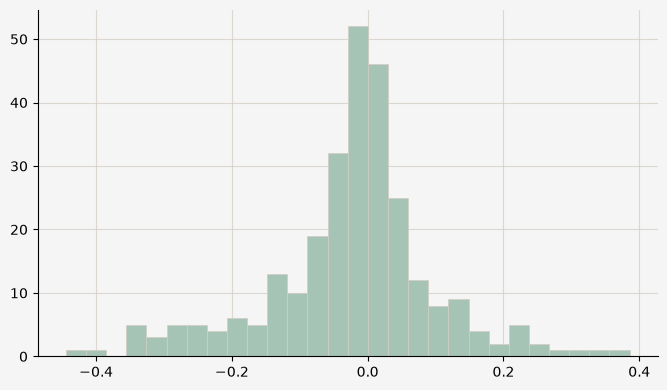

In [23]:
plotting_tools.pretty_histogram(feature_etas["delta_eta_2"])

In [26]:
feature_etas.sort_values(by='eta_2_final', ascending=False)[:20]

,feature_x,eta_2_final,feature_y,eta_2,delta_eta_2
129,fin2.t.d,0.918538,fin2.t.d,0.905652,-0.012886
85,fiaccount.t.d,0.883384,fiaccount.t.d,0.852878,-0.030506
190,fin3,0.809324,fin3,0.780230,-0.029094
78,con9a,0.801653,con9a,0.892978,0.091325
276,internet,0.801646,internet,0.899118,0.097473
238,fin4.d,0.797517,fin4.d,0.764816,-0.032702
0,account.t.d,0.795814,account.t.d,0.801341,0.005527
255,fin5m,0.782052,fin5m,0.748467,-0.033585
265,fin9b,0.780640,fin9b,0.728932,-0.051709
211,fin34a,0.761793,fin34a,0.739972,-0.021821


In [28]:
feature = 'mobileaccount.t.d'
feature_etas[feature_etas['feature_x'] == feature]

,feature_x,eta_2_final,feature_y,eta_2,delta_eta_2
278,mobileaccount.t.d,0.501639,mobileaccount.t.d,0.26105,-0.240589
